**Welcome to your First Graded Assignment on Machine Learning!**

## Employee Churn Dataset

About the Data

This dataset contains information about employees in a company, including their educational backgrounds, work history, demographics, and employment-related factors. It has been anonymized to protect privacy while still providing valuable insights into the workforce.

Goal:- The classification goal is to predict if the Employee will Churn / Attrition (1 / 0) in the company.

Features of train data are listed below


1. **Education:** The educational qualifications of employees, including degree, institution, and field of study.

2. **Joining Year:** The year each employee joined the company, indicating their length of service.

3. **City:** The location or city where each employee is based or works.

4. **Payment Tier:** Categorization of employees into different salary tiers.

5. **Age:** The age of each employee, providing demographic insights.

6. **Gender:** Gender identity of employees, promoting diversity analysis.

7. **Ever Benched:** Indicates if an employee has ever been temporarily without assigned work.

8. **Experience in Current Domain:** The number of years of experience employees have in their current field.

Target Column

9. **Leave or Not:** Whether employee left us or Not (1 = Left)

---

**What is our Key target for ML?**

Are there any patterns in leave-taking behavior among employees?

You will find the answer to this question at EDA and also last stage of ML wher you interpret and find most influential features (Importance) to predict "Leave"


**Requirements: (TOTAL 75 Marks)**



**DATA CLEANING (5 Marks)**

Import data, Clean it and check necessary with steps, Look for Data Types & Duplicate.

The following Data Cleaning Steps need to be ensured:
- Make sure there is No Duplicate Data
- You do describe and Info for Null Values explore
- You transform Target Column 1 (Leave) and 0 as (Stay)

You need to conduct **Exploratory Data Analysis (Total Segment Marks (9 + 5 + 3) * 2 = 34 Marks** :

1. Univariate Analysis
- For All Variables

2. Bi Variate Analysis Against Target
- For 5 Important Variables you think

3. Multi Variate to Uncover Complex Relatinships
- For 3 Variables you think should be looked into combination

Format in General (Extend it)

- Analysis Cell (Your Code and Chart is here) 1 Marks
- Insight Cell (What did you learn from above Chart / Analysis) 1 Marks

---

Step 4 : **Features Preparation & Engineering (16 Marks)**

You shall need to treat Numerical and Categorical Variables to be Machine Learning model ready.

- Scale Numerical Values (2 Marks for Each Numerical Variable) : https://geekpython.in/how-to-use-sklearn-standardscaler

- One Hot Encode Categorical Values (2 Marks for Each Categorical Variable) : https://datasensei.medium.com/how-to-transform-nominal-data-for-ml-with-onehotencoder-from-scikit-learn-f6febfefb3c6

---

Step 5 : **Splitting Data for Training & Test Evaluation (3 Marks)**

Step 6 : **Model Building (Train 3 Models Logistic vs DT vs RF) (6 Marks)**

Step 7 : **Model Evaluation (Define a Metric you selected for the Problem) (4 Marks)**

* 1 Marks for Selection between Accuracy Recall or Precision
* 1 Marks for Reasoning
* 1 Marks for Evaluation Interpretation

(Compare Model Performance based on chosen Metric and Iterate between Step 7 - 8 to finalize the Best 1)

* 1 Marks for Selection of Best Model

---

Step 8 : **Testing the Model on (Splited Test Data) (2 Marks)**

- Interpret the Classification Report

(Comment on the Gap between Training and Testing Accuracy - is it overfit?)

---

Step 9 : **Interpretation & Learning from Modelling (5 Marks)**

Call in the RF / Logistic Model Important Feature Charts or Decision Tree Visualization to share insights on Learned Important Features / Rules of Classification of Employees of who leave us to answer the Ultimate Question.


**Good luck!**

### **Importing Data**

In [1]:
## Importing Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler , StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,recall_score,f1_score,precision_score 

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


import pickle
import dill


In [2]:
## Reading the dataset
df = pd.read_csv("E:/CDA/csv/Employee - Employee.csv")
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [3]:
df.sample(5)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
2464,Bachelors,2013,New Delhi,3,26,Male,No,4,0
4139,Bachelors,2017,Bangalore,3,37,Male,No,3,1
960,Bachelors,2017,Pune,3,24,Male,No,2,0
2262,Bachelors,2013,Bangalore,3,26,Male,No,4,0
4281,Bachelors,2013,Bangalore,3,37,Female,No,4,0


In [4]:
df.info()
# No null data point found 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


### **Data Cleaning**

In [5]:
df['Education'].unique()

array(['Bachelors', 'Masters', 'PHD'], dtype=object)

In [6]:
df['City'].unique()

array(['Bangalore', 'Pune', 'New Delhi'], dtype=object)

In [7]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [8]:
df['EverBenched'].unique()

array(['No', 'Yes'], dtype=object)

In [9]:
df.shape

(4653, 9)

In [10]:
df['LeaveOrNot'].value_counts()

LeaveOrNot
0    3053
1    1600
Name: count, dtype: int64

In [11]:
df.duplicated().sum()
# total 1889 data points are duplicated , need to transform 

1889

In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [13]:
df.reset_index(drop=True, inplace=True) # reset index

In [14]:
df.shape

(2764, 9)

In [15]:
df.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [16]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,2764.000000,2764.000000,2764.000000,2764.000000,2764.000000
mean,2015.090449,2.636035,30.952967,2.644356,0.393632
std,1.885943,0.624001,5.108872,1.610610,0.488643
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,2.000000,27.000000,1.000000,0.000000
50%,2015.000000,3.000000,30.000000,2.000000,0.000000
75%,2017.000000,3.000000,35.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [17]:
 df['LeaveOrNot'].value_counts()

LeaveOrNot
0    1676
1    1088
Name: count, dtype: int64

In [18]:
 df['LeaveOrNot'].value_counts(normalize=True)*100

LeaveOrNot
0    60.636758
1    39.363242
Name: proportion, dtype: float64

In [19]:
df['LeaveOrNot']=df['LeaveOrNot'].map({0:"Stay" , 1:"Leave"})

In [20]:
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,Stay
1,Bachelors,2013,Pune,1,28,Female,No,3,Leave
2,Bachelors,2014,New Delhi,3,38,Female,No,2,Stay
3,Masters,2016,Bangalore,3,27,Male,No,5,Leave
4,Masters,2017,Pune,3,24,Male,Yes,2,Leave
...,...,...,...,...,...,...,...,...,...
2759,Masters,2017,Pune,2,31,Female,No,2,Stay
2760,Bachelors,2016,Pune,3,30,Male,No,2,Stay
2761,Masters,2013,Pune,2,37,Male,No,2,Leave
2762,Masters,2018,New Delhi,3,27,Male,No,5,Leave


In [21]:
df['LeaveOrNot'].value_counts()

LeaveOrNot
Stay     1676
Leave    1088
Name: count, dtype: int64

In [22]:
num_col = df.select_dtypes(include=["int64","float64"]).columns.tolist()
obj_col =df.select_dtypes(include=['object']).columns.tolist()


In [23]:
num_col

['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']

In [24]:
obj_col

['Education', 'City', 'Gender', 'EverBenched', 'LeaveOrNot']

In [25]:
obj_col = obj_col[:-1]
obj_col

['Education', 'City', 'Gender', 'EverBenched']

In [26]:
def numericalOutliers (df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    print(f"{col}")
    print(f"Outliers above {upper}: {(df[col] > upper).sum()}")
    print(f"Outliers under {lower}: {(df[col] < lower).sum()}")
    print(f"\n")
    
    return(lower , upper)


In [27]:
for data in num_col:
    numericalOutliers(df, data)
    

JoiningYear
Outliers above 2023.0: 0
Outliers under 2007.0: 0


PaymentTier
Outliers above 4.5: 0
Outliers under 0.5: 0


Age
Outliers above 47.0: 0
Outliers under 15.0: 0


ExperienceInCurrentDomain
Outliers above 8.5: 0
Outliers under -3.5: 0




### **Exploratory Data Analysis**

#### UNIVARIATE

In [28]:
def create_histogram_uni(df, var, bins=15, kde=True, cmap='viridis', title=None, xlabel=None, ylabel='Count', figsize=(10, 6)):
    # Create the histogram with gradient coloring
    plt.figure(figsize=figsize)
    hist = sns.histplot(
        data=df,
        x=var,
        bins=bins,
        kde=kde,
        palette=cmap,
        edgecolor=None
    )

    # Create a colormap and apply a color gradient
    counts, bin_edges = np.histogram(df[var].dropna(), bins=bins)
    norm = plt.Normalize(vmin=0, vmax=max(counts))
    for i, bar in enumerate(hist.patches):
        bar.set_facecolor(plt.cm.get_cmap(cmap)(norm(counts[i])))

    # Titles and labels
    plt.title(title or f'{var} Distribution')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)
    plt.show()


def create_chart_uni(
    df,
    var,
    colors=None,
    explode=None,
    cmap='plasma',
    autopct='%.0f%%',
    title=None,
    figsize=(10, 6)
):

    # value counts for pie chart
    values = df[var].value_counts()
    labels = values.index

    # default colors
    if colors is None:
        colors = sns.color_palette('viridis')

    # default explode
    if explode is None:
        explode = [0] * len(values)

    plt.figure(figsize=figsize)

    plt.pie(
        values,
        labels=labels,
        colors=colors[:len(values)],
        explode=explode,
        autopct=autopct
    )

    plt.title(title or f'{var} Distribution')
    plt.show()


def create_bar_uni(df, var, title=None, xlabel=None, ylabel='Count', palette='pastel', figsize=(8, 6)):
    # Get sorted categories by count and calculate percentages
    category_counts = df[var].value_counts()
    sorted_categories = category_counts.index
    total_count = len(df)
    category_percentages = (category_counts / total_count) * 100

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=df, x=var, order=sorted_categories, palette=palette)
    plt.title(title or f'{var} Distribution')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)

    # Add labels on each bar
    for p, percentage in zip(ax.patches, category_percentages):
        ax.annotate(f'{p.get_height()} ({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

    return plt

C:\Users\User\AppData\Local\Temp\ipykernel_25484\886277049.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  hist = sns.histplot(
C:\Users\User\AppData\Local\Temp\ipykernel_25484\886277049.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar.set_facecolor(plt.cm.get_cmap(cmap)(norm(counts[i])))


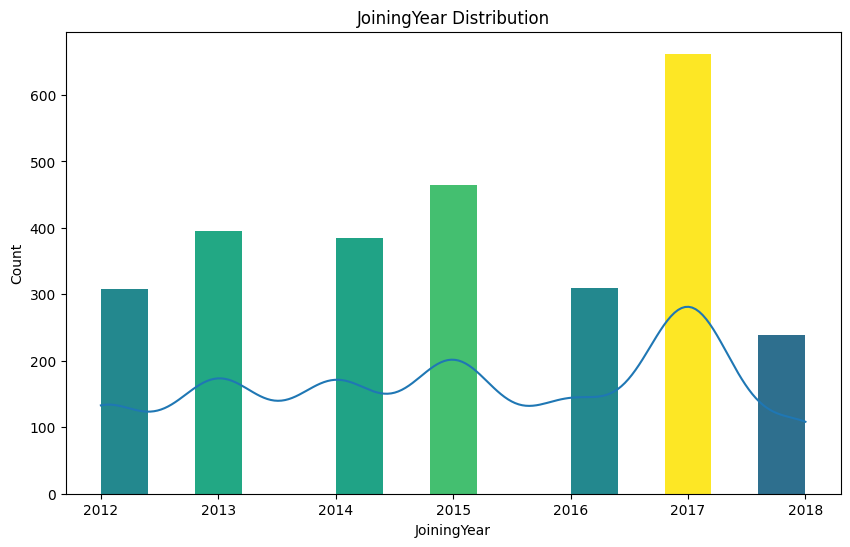

In [29]:
create_histogram_uni(df, 'JoiningYear')

C:\Users\User\AppData\Local\Temp\ipykernel_25484\886277049.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  hist = sns.histplot(
C:\Users\User\AppData\Local\Temp\ipykernel_25484\886277049.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar.set_facecolor(plt.cm.get_cmap(cmap)(norm(counts[i])))


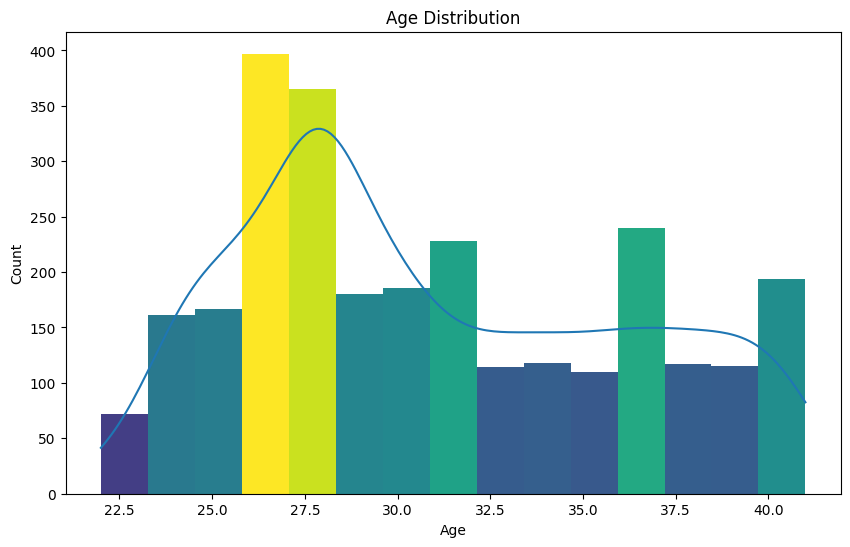

In [30]:
create_histogram_uni(df, 'Age')

C:\Users\User\AppData\Local\Temp\ipykernel_25484\886277049.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  hist = sns.histplot(
C:\Users\User\AppData\Local\Temp\ipykernel_25484\886277049.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar.set_facecolor(plt.cm.get_cmap(cmap)(norm(counts[i])))


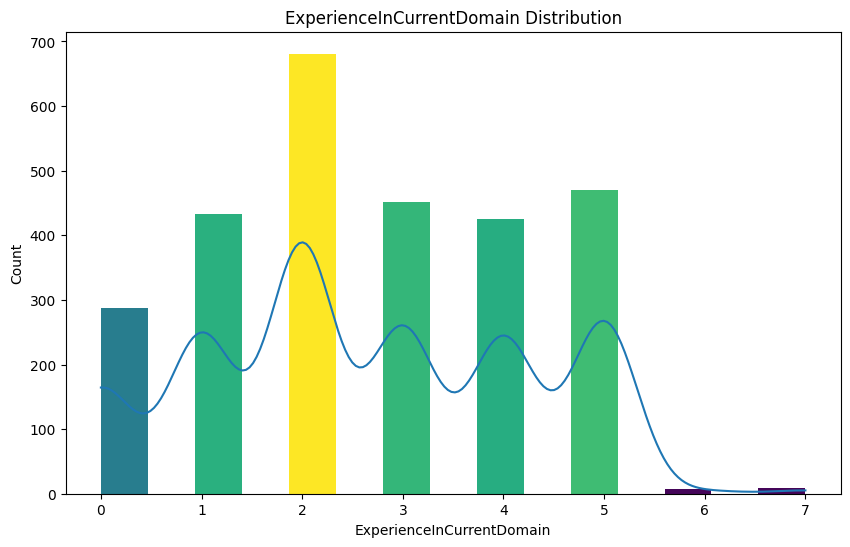

In [31]:
create_histogram_uni(df, 'ExperienceInCurrentDomain')

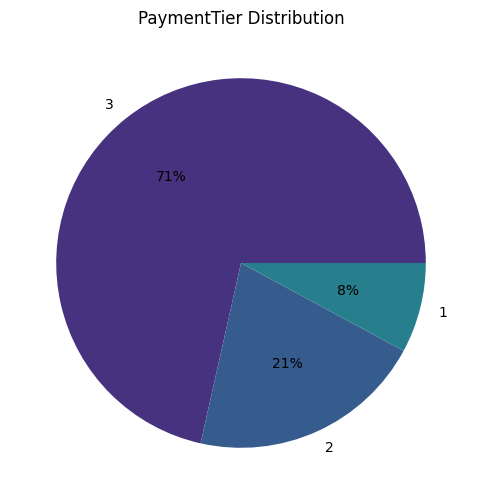

In [32]:
create_chart_uni(df , 'PaymentTier')

<module 'matplotlib.pyplot' from 'E:\\CDA\\assignment\\assignment with frontend\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

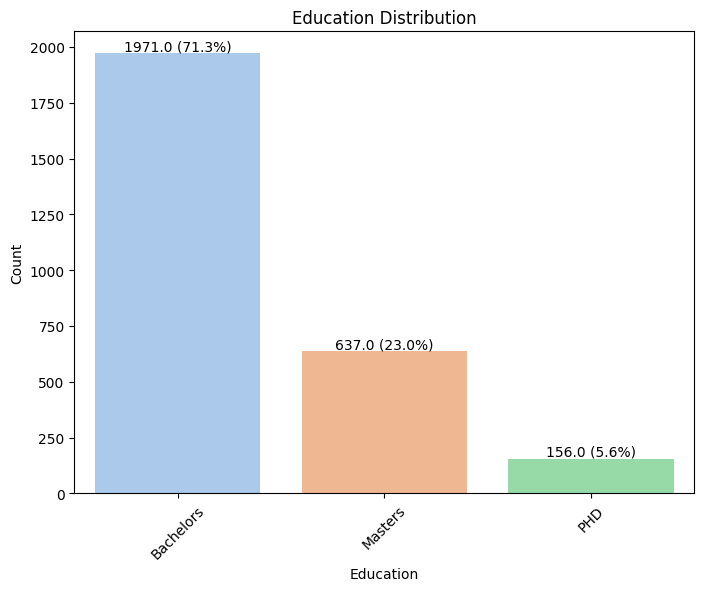

In [33]:
create_bar_uni(df,"Education")

<module 'matplotlib.pyplot' from 'E:\\CDA\\assignment\\assignment with frontend\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

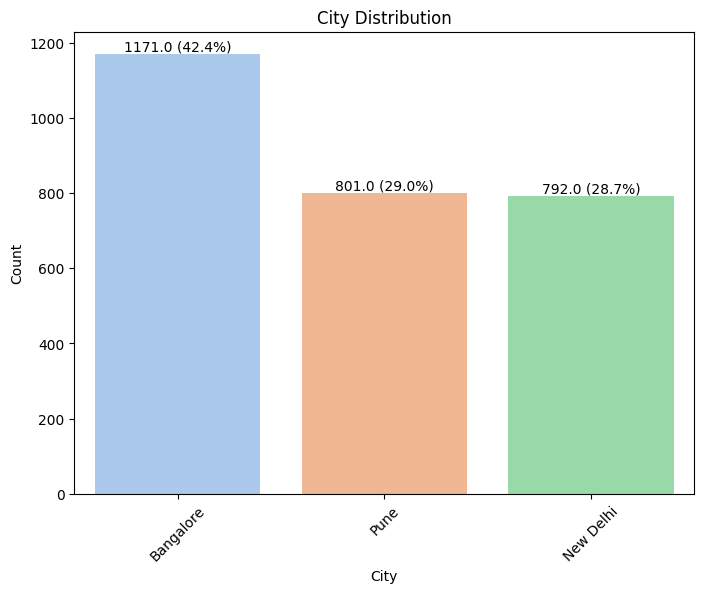

In [34]:
create_bar_uni(df,"City")

<module 'matplotlib.pyplot' from 'E:\\CDA\\assignment\\assignment with frontend\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

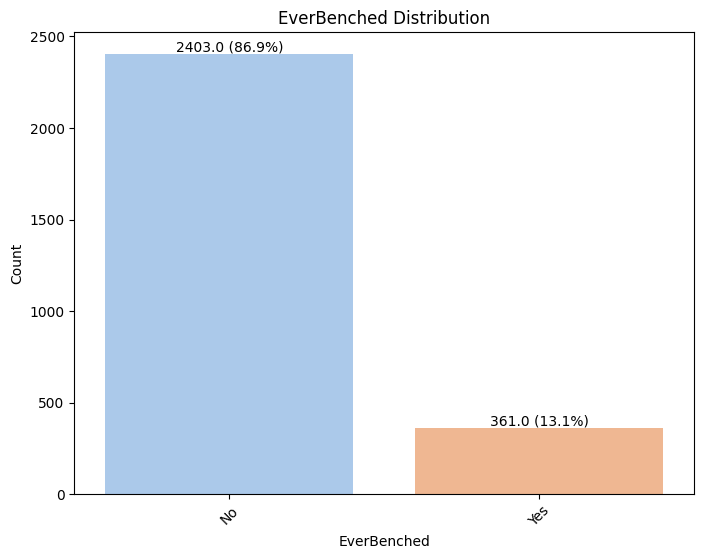

In [35]:
create_bar_uni(df,"EverBenched")

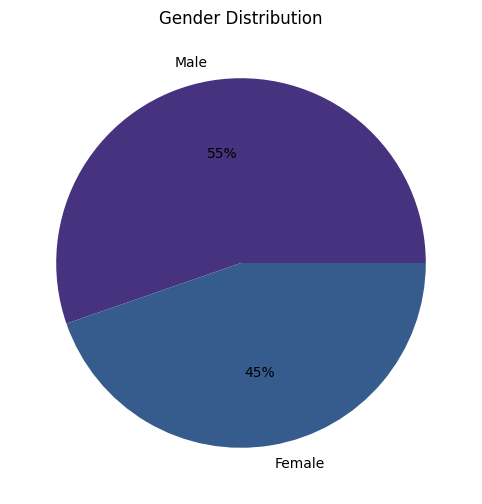

In [36]:
create_chart_uni(df , 'Gender')

<module 'matplotlib.pyplot' from 'E:\\CDA\\assignment\\assignment with frontend\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

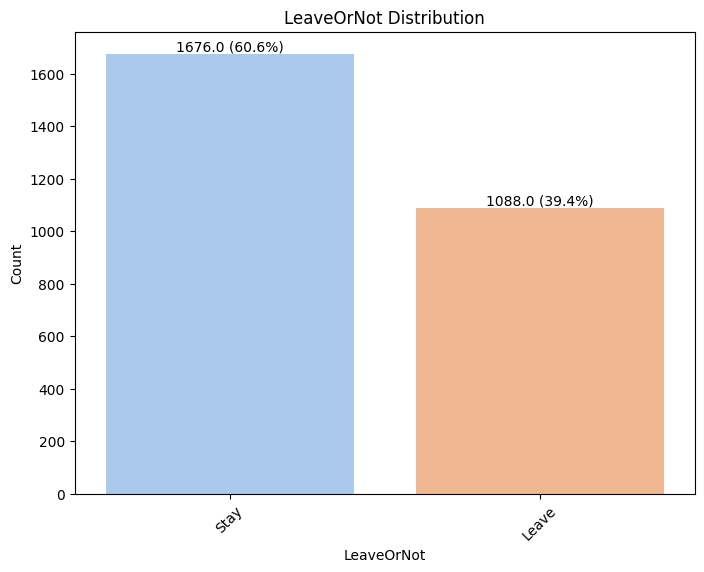

In [37]:
create_bar_uni(df,"LeaveOrNot")

#### BI VARIATE

##### FIRST COMBINATION OF 2 VARS

In [38]:

def create_histogram_bi(df, var, hue=None, bins=20, kde=True, color='skyblue', title=None, xlabel=None, ylabel='Count', figsize=(10, 6)):
    plt.figure(figsize=figsize)
    sns.histplot(data=df, x=var, hue=hue, bins=bins, kde=kde, color=color)
    plt.title(title or f'{var} Distribution against {hue}')
    plt.xlabel(xlabel or var)
    plt.ylabel(ylabel)
    plt.show()

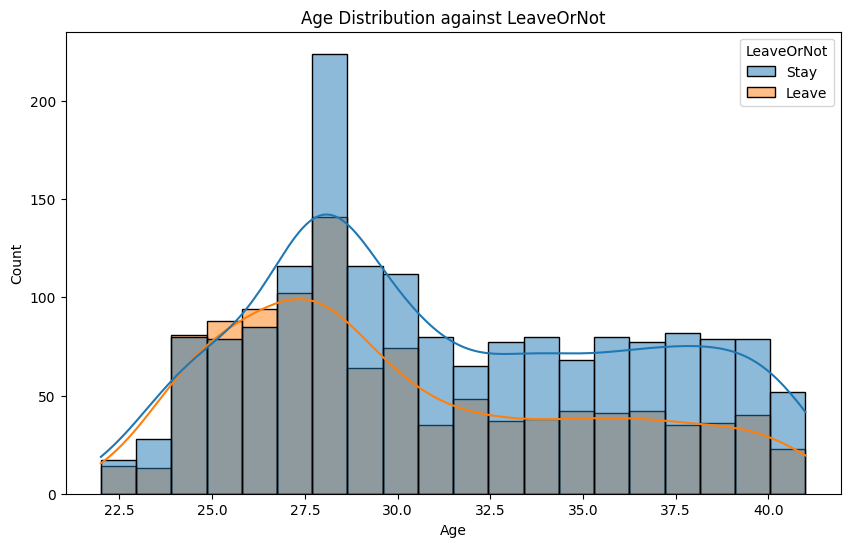

In [39]:
create_histogram_bi(df, var='Age', hue='LeaveOrNot' ,bins=20)

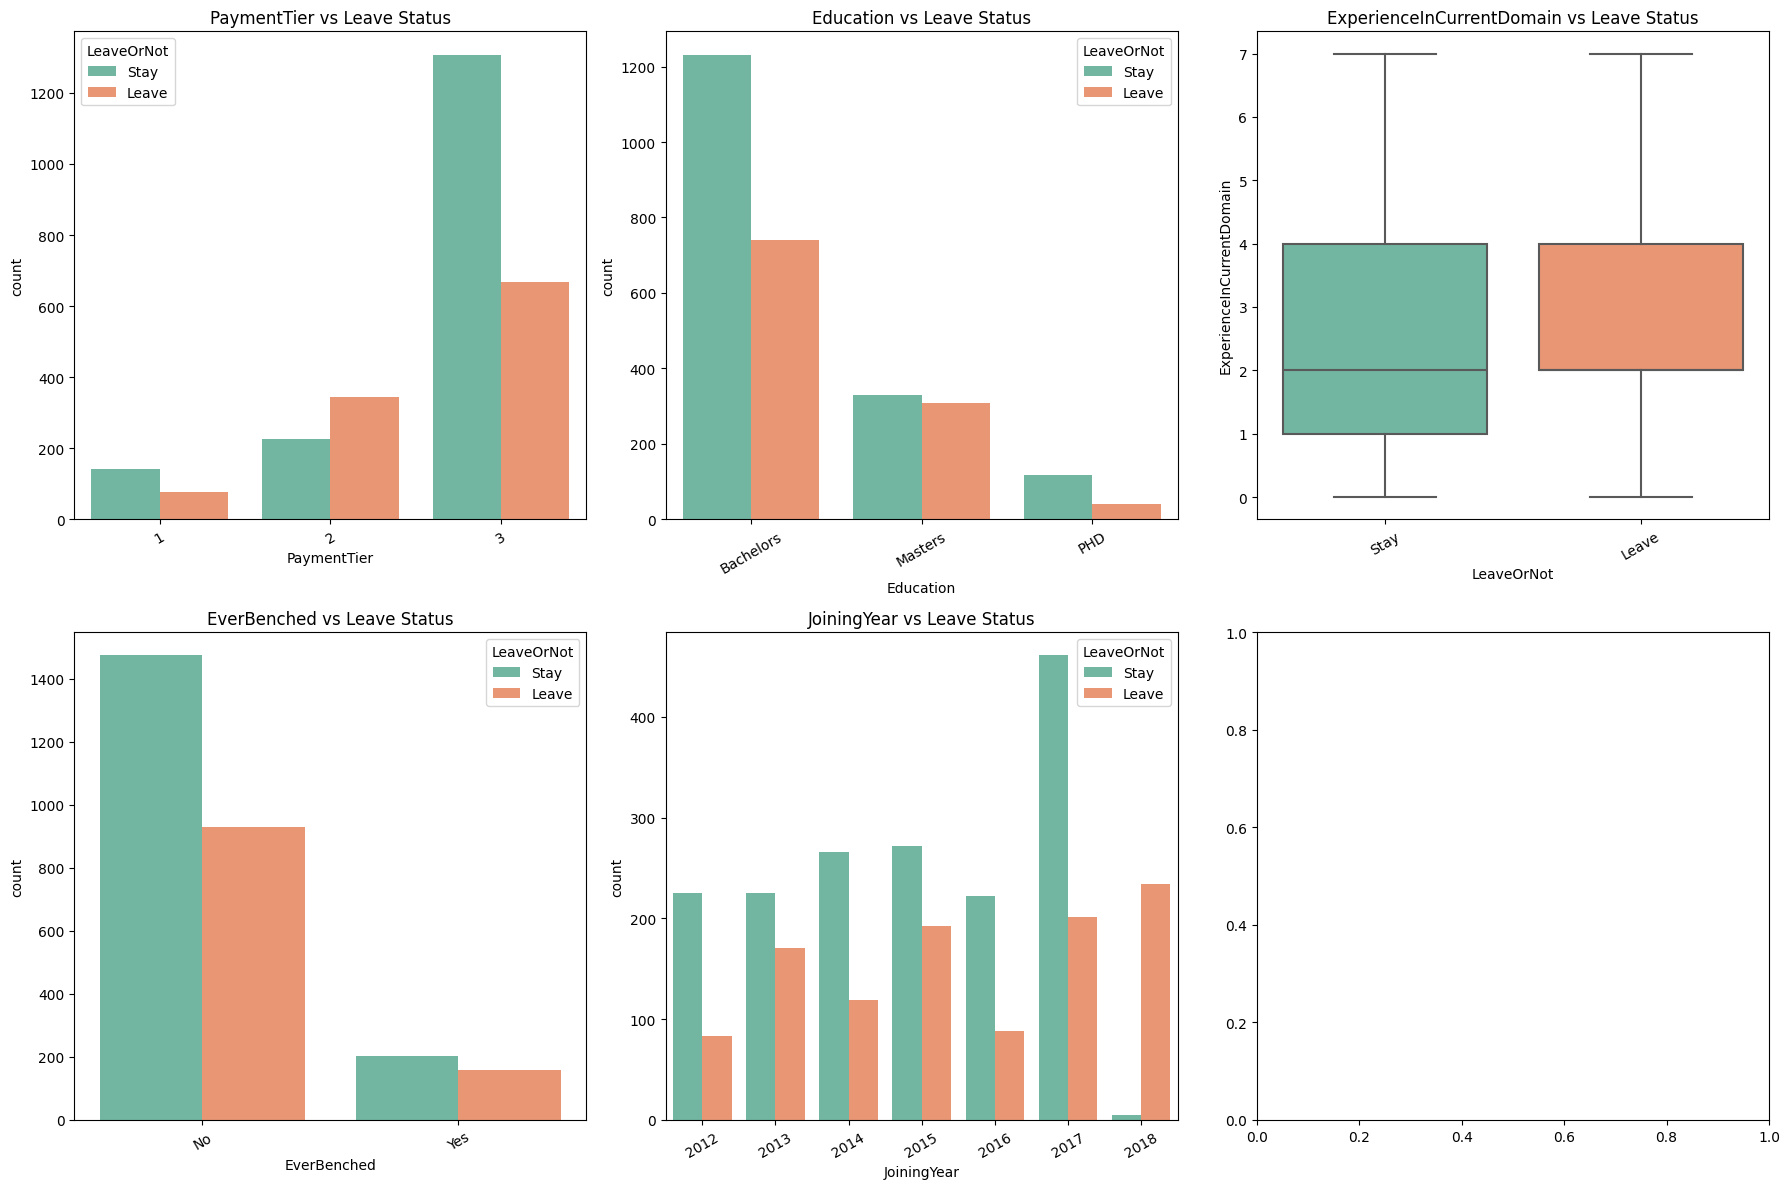

In [40]:
important_vars = ['PaymentTier', 'Education', 'ExperienceInCurrentDomain', 'EverBenched', 'JoiningYear']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(important_vars):
    if df[col].dtype == 'object' or col in ['PaymentTier', 'JoiningYear' ]:
        sns.countplot(data=df, x=col, hue='LeaveOrNot', ax=axes[i], palette="Set2")
    else:
        sns.boxplot(data=df, x='LeaveOrNot', y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f'{col} vs Leave Status')
    axes[i].tick_params(axis='x', rotation=30)

# Delete the unused 6th subplot axis
#fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

#### MULTI VARIATE

##### FIRST COMBINATION OF MORE THAN 2 VARS

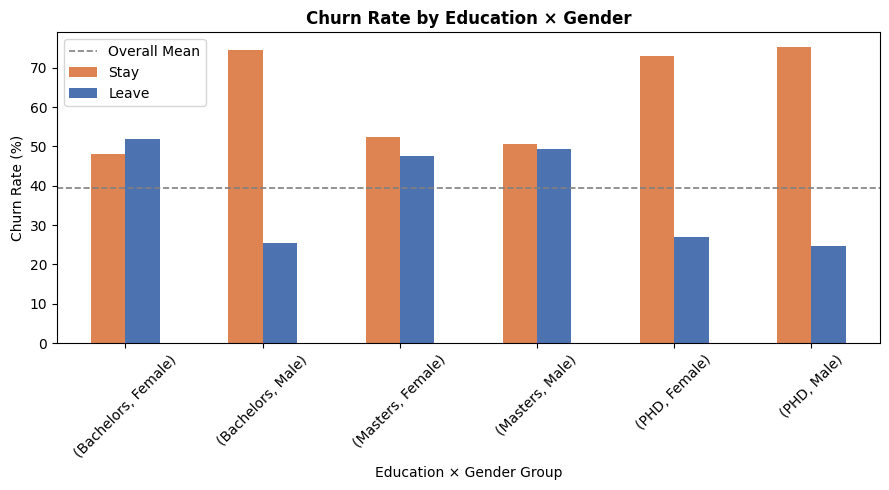

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

# 1. Create the temporary variable and calculate the grouped mean 
edu_gender_churn = (
    df.assign(Leave_Numeric=df['LeaveOrNot'].map({'Stay': 0, 'Leave': 1}))
    .groupby(['Education', 'Gender'])['Leave_Numeric'] 
    .value_counts(normalize=True).unstack(fill_value=0) * 100
)

# 2. Plot the bar chart
edu_gender_churn.plot(kind='bar', color=['#DD8452', '#4C72B0'], ax=ax)

ax.set_title('Churn Rate by Education × Gender', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Education × Gender Group')
ax.tick_params(axis='x', rotation=45) 

# 3. Calculate the correct overall benchmark mean from the mapped data
overall_mean = df['LeaveOrNot'].map({'Stay': 0, 'Leave': 1}).mean() * 100
ax.axhline(overall_mean, color='grey', linestyle='--', linewidth=1.2, label='Overall Mean')
ax.legend([ 'Overall Mean' , 'Stay', 'Leave', ])
plt.tight_layout()
plt.show()


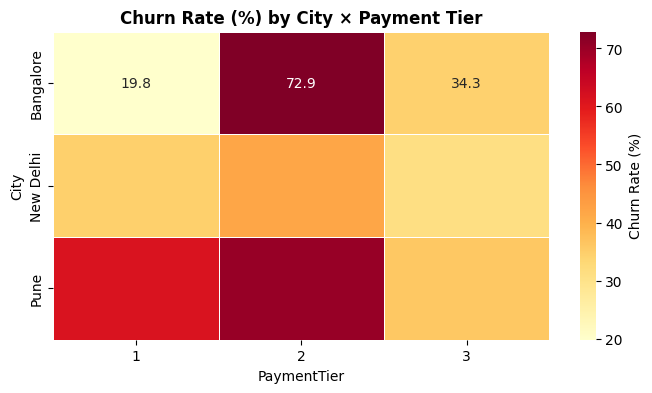

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
pivot = (
    df.assign(Leave_Numeric=df['LeaveOrNot'].map({'Stay': 0, 'Leave': 1}))
    .pivot_table(values='Leave_Numeric', index='City', columns='PaymentTier', aggfunc='mean') * 100
)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Churn Rate (%)'}, ax=ax)
ax.set_title('Churn Rate (%) by City × Payment Tier', fontweight='bold')
plt.show()


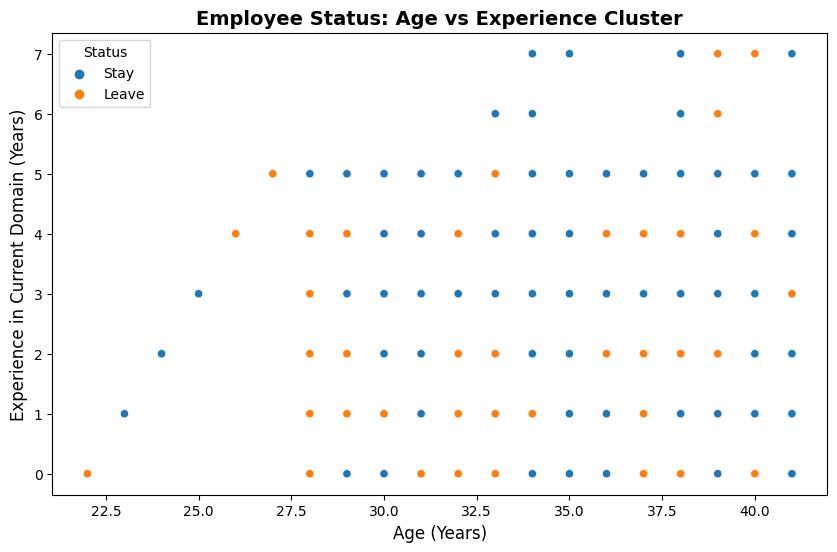

In [43]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='ExperienceInCurrentDomain', 
    hue='LeaveOrNot', 
    ax=ax
)

ax.set_title('Employee Status: Age vs Experience Cluster', fontweight='bold', fontsize=14)
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Experience in Current Domain (Years)', fontsize=12)
ax.legend(title='Status')

plt.show()


### **Feature Engineering**

In [44]:
FEATURES = ['Education', 'JoiningYear', 'City', 'PaymentTier',
            'Age', 'Gender', 'EverBenched', 'ExperienceInCurrentDomain']

TARGET = 'LeaveOrNot'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print('Feature matrix shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Feature matrix shape: (2764, 8)
Target distribution:
LeaveOrNot
Stay     1676
Leave    1088
Name: count, dtype: int64


In [45]:
X.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain
count,2764.000000,2764.000000,2764.000000,2764.000000
mean,2015.090449,2.636035,30.952967,2.644356
std,1.885943,0.624001,5.108872,1.610610
min,2012.000000,1.000000,22.000000,0.000000
25%,2013.000000,2.000000,27.000000,1.000000
50%,2015.000000,3.000000,30.000000,2.000000
75%,2017.000000,3.000000,35.000000,4.000000
max,2018.000000,3.000000,41.000000,7.000000


In [46]:
num_col

['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']

In [47]:
obj_col 

['Education', 'City', 'Gender', 'EverBenched']

### **Spliting the data**

In [48]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
X_train.shape

(2211, 8)

In [50]:
X_test.shape

(553, 8)

In [51]:
y_train.value_counts(normalize=True)

LeaveOrNot
Stay     0.607417
Leave    0.392583
Name: proportion, dtype: float64

In [52]:
y_test.value_counts(normalize=True)

LeaveOrNot
Stay     0.60217
Leave    0.39783
Name: proportion, dtype: float64

In [53]:
print('Train Data','\n',y_train.value_counts(normalize=True),'\n','\n','Test Data','\n', y_test.value_counts(normalize=True))

Train Data 
 LeaveOrNot
Stay     0.607417
Leave    0.392583
Name: proportion, dtype: float64 
 
 Test Data 
 LeaveOrNot
Stay     0.60217
Leave    0.39783
Name: proportion, dtype: float64


### **Generate & Export Schema**

In [54]:
X.select_dtypes(include=[np.float64,np.int64]).head()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain
0,2017,3,34,0
1,2013,1,28,3
2,2014,3,38,2
3,2016,3,27,5
4,2017,3,24,2


In [55]:
X.Age.value_counts()

Age
28    365
27    218
30    186
29    180
26    179
25    167
24    161
36    121
40    119
37    119
34    118
38    117
39    115
31    115
33    114
32    113
35    110
41     75
23     41
22     31
Name: count, dtype: int64

In [56]:
X.JoiningYear.value_counts()

JoiningYear
2017    662
2015    464
2013    396
2014    385
2016    310
2012    308
2018    239
Name: count, dtype: int64

In [57]:
X.PaymentTier.value_counts()

PaymentTier
3    1976
2     570
1     218
Name: count, dtype: int64

In [58]:
X.PaymentTier.map({1 : 'Low' , 2 : 'Medium' , 3:'High' }).value_counts()

PaymentTier
High      1976
Medium     570
Low        218
Name: count, dtype: int64

In [59]:
X.ExperienceInCurrentDomain.value_counts()

ExperienceInCurrentDomain
2    681
5    470
3    451
1    433
4    425
0    287
7      9
6      8
Name: count, dtype: int64

In [60]:
X.select_dtypes(include=[object]).head()

,Education,City,Gender,EverBenched
0,Bachelors,Bangalore,Male,No
1,Bachelors,Pune,Female,No
2,Bachelors,New Delhi,Female,No
3,Masters,Bangalore,Male,No
4,Masters,Pune,Male,Yes


In [61]:
categorical_features = X.select_dtypes(include=[object]).columns

categorical_features = list(categorical_features) + ['PaymentTier']

print('\n','Categorical Features','\n', categorical_features,'\n')


 Categorical Features 
 ['Education', 'City', 'Gender', 'EverBenched', 'PaymentTier'] 



In [62]:
numerical_features = list(X.select_dtypes(include=[np.float64,np.int64]).columns.difference(['PaymentTier']))

print('\n','Numerical Features','\n', numerical_features,'\n')


 Numerical Features 
 ['Age', 'ExperienceInCurrentDomain', 'JoiningYear'] 



In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  2764 non-null   object
 1   JoiningYear                2764 non-null   int64 
 2   City                       2764 non-null   object
 3   PaymentTier                2764 non-null   int64 
 4   Age                        2764 non-null   int64 
 5   Gender                     2764 non-null   object
 6   EverBenched                2764 non-null   object
 7   ExperienceInCurrentDomain  2764 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 172.9+ KB


In [64]:
print(X_train.columns.tolist())

['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender', 'EverBenched', 'ExperienceInCurrentDomain']


In [65]:
def summarize_cat(data,categorical_features):
  results=[]

  for column in data[categorical_features]:
      # Get the unique members of the column
      members = data[column].unique().tolist()
      # Append the column name and its unique members to the results list
      results.append([column, members])

  return pd.DataFrame(results, columns=['Column Name', 'Members'])

# Create a DataFrame from the results list
summarize_cat(X_train,categorical_features)

,Column Name,Members
0,Education,"[Bachelors, Masters, PHD]"
1,City,"[Bangalore, New Delhi, Pune]"
2,Gender,"[Male, Female]"
3,EverBenched,"[No, Yes]"
4,PaymentTier,"[2, 3, 1]"


In [66]:
summarize_cat(df,categorical_features).to_dict()

{'Column Name': {0: 'Education',
  1: 'City',
  2: 'Gender',
  3: 'EverBenched',
  4: 'PaymentTier'},
 'Members': {0: ['Bachelors', 'Masters', 'PHD'],
  1: ['Bangalore', 'Pune', 'New Delhi'],
  2: ['Male', 'Female'],
  3: ['No', 'Yes'],
  4: [3, 1, 2]}}

In [67]:
numerical_features

['Age', 'ExperienceInCurrentDomain', 'JoiningYear']

In [68]:
# EXPORTING FOR DE
my_feature_dict = {'CATEGORICAL' : summarize_cat(df,categorical_features).to_dict(), 'NUMERICAL' : {'Column Name': numerical_features}}

my_feature_dict.get('NUMERICAL')

{'Column Name': ['Age', 'ExperienceInCurrentDomain', 'JoiningYear']}

In [69]:
my_feature_dict

{'CATEGORICAL': {'Column Name': {0: 'Education',
   1: 'City',
   2: 'Gender',
   3: 'EverBenched',
   4: 'PaymentTier'},
  'Members': {0: ['Bachelors', 'Masters', 'PHD'],
   1: ['Bangalore', 'Pune', 'New Delhi'],
   2: ['Male', 'Female'],
   3: ['No', 'Yes'],
   4: [3, 1, 2]}},
 'NUMERICAL': {'Column Name': ['Age',
   'ExperienceInCurrentDomain',
   'JoiningYear']}}

In [70]:

# save dictionary to person_data.pkl file
with open('my_feature_dict.pkl', 'wb') as fp:
    pickle.dump(my_feature_dict, fp)
    print('dictionary saved successfully to file')

dictionary saved successfully to file


#### **CREATING THE PIPELINE**

In [71]:

# PREPROCESSING TRANSFORMATIONS ARE DONE ON EXAMPLE BASIS
# REAL WORLD SELECTION OF PREPROCSSING TRANSFORMATIONS MUST BE LOGICAL

transform_PaymentTier = lambda x: x.assign(PaymentTier=x['PaymentTier'].map({1 : 'Low' , 2 : 'Medium' , 3:'High'}))

preprocessor_stage_1 = Pipeline(steps=[
    ('transform_pt', FunctionTransformer(transform_PaymentTier)),
])



pipeline_num = Pipeline(steps=[
    ('scale_data', StandardScaler()),
    ('simple_imputer1', SimpleImputer(strategy='constant',fill_value=0)),
])


pipeline_cat = Pipeline(steps=[
    ('OneHotEncode', OneHotEncoder(handle_unknown="ignore" , sparse_output=False , drop='first'))
])


preprocessor_stage_2 = ColumnTransformer(
    transformers=[
        ('cat', pipeline_cat, categorical_features),  # Categorical columns
        ('num', pipeline_num, numerical_features),     # Numerical columns
    ],remainder='drop')

preprocessor_stack = Pipeline(steps=[
    ('preprocessor_stage_1', preprocessor_stage_1),
    ('preprocessor_stage_2', preprocessor_stage_2)
])



In [72]:
preprocessor_stack

Pipeline(steps=[('preprocessor_stage_1',
                 Pipeline(steps=[('transform_pt',
                                  FunctionTransformer(func=<function <lambda> at 0x00000287BD891EE0>))])),
                ('preprocessor_stage_2',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('OneHotEncode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Education', 'City',
                                                   'Gender', 'EverBenched',
                                                   'PaymentTier']),
                                                 ('num',
                                                  Pipeline(steps=[('scale_data',
                                                                   StandardScaler()),
                                                                  ('simple_imputer1',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['Age',
                                                   'ExperienceInCurrentDomain',
                                                   'JoiningYear'])]))])

In [73]:
X_train.PaymentTier.value_counts()

PaymentTier
3    1571
2     462
1     178
Name: count, dtype: int64

In [74]:
preprocessor_stage_1.fit_transform(X_train).PaymentTier.value_counts()

PaymentTier
High      1571
Medium     462
Low        178
Name: count, dtype: int64

#### **FITTING THE PIPELINE**


In [75]:
preprocessor_stack.fit(X_train)

Pipeline(steps=[('preprocessor_stage_1',
                 Pipeline(steps=[('transform_pt',
                                  FunctionTransformer(func=<function <lambda> at 0x00000287BD891EE0>))])),
                ('preprocessor_stage_2',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('OneHotEncode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Education', 'City',
                                                   'Gender', 'EverBenched',
                                                   'PaymentTier']),
                                                 ('num',
                                                  Pipeline(steps=[('scale_data',
                                                                   StandardScaler()),
                                                                  ('simple_imputer1',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['Age',
                                                   'ExperienceInCurrentDomain',
                                                   'JoiningYear'])]))])

In [76]:
pd.DataFrame(preprocessor_stack.transform(X_train),columns=preprocessor_stack[-1].get_feature_names_out())

,cat__Education_Masters,cat__Education_PHD,cat__City_New Delhi,cat__City_Pune,cat__Gender_Male,cat__EverBenched_Yes,cat__PaymentTier_Low,cat__PaymentTier_Medium,num__Age,num__ExperienceInCurrentDomain,num__JoiningYear
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.773695,-1.639104,1.016242
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.382737,-1.017268,-0.586786
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.594661,1.470075,-1.655472
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.594661,-1.017268,1.016242
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.985620,0.848239,-0.586786
...,...,...,...,...,...,...,...,...,...,...,...
2206,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.187257,-1.017268,1.016242
2207,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.594661,-1.017268,0.481899
2208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.203702,-0.395432,-1.655472
2209,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,-0.203702,-1.017268,-1.121129


In [77]:
y_train

2750     Stay
1849    Leave
651      Stay
261      Stay
1253     Stay
        ...  
1638    Leave
1095     Stay
1130     Stay
1294    Leave
860     Leave
Name: LeaveOrNot, Length: 2211, dtype: object

In [78]:

trained_pipelines = {}
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_stack),
    ('classifier', RandomForestClassifier())
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('preprocessor_stage_1',
                                  Pipeline(steps=[('transform_pt',
                                                   FunctionTransformer(func=<function <lambda> at 0x00000287BD891EE0>))])),
                                 ('preprocessor_stage_2',
                                  ColumnTransformer(transformers=[('cat',
                                                                   Pipeline(steps=[('OneHotEncode',
                                                                                    OneHotEncoder(drop='first',
                                                                                                  handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['Education',
                                                                    'City',
                                                                    'Gender',
                                                                    'EverBenched',
                                                                    'PaymentTier']),
                                                                  ('num',
                                                                   Pipeline(steps=[('scale_data',
                                                                                    StandardScaler()),
                                                                                   ('simple_imputer1',
                                                                                    SimpleImputer(fill_value=0,
                                                                                                  strategy='constant'))]),
                                                                   ['Age',
                                                                    'ExperienceInCurrentDomain',
                                                                    'JoiningYear'])]))])),
                ('classifier', RandomForestClassifier())])

In [79]:
X_train.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
2750,Bachelors,2017,Bangalore,2,35,Male,No,0
1849,Bachelors,2014,Bangalore,3,33,Male,No,1
651,Bachelors,2012,Bangalore,3,28,Male,No,5
261,Bachelors,2017,New Delhi,2,28,Male,No,1
1253,Bachelors,2014,Bangalore,3,26,Female,Yes,4


In [80]:
# Checking Training Accuracy
y_train_pred = pipeline.predict(X_train)

print("Accuracy:", accuracy_score(y_train,y_train_pred))
print("\nClassification Report:\n", classification_report(y_train,y_train_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train,y_train_pred))

Accuracy: 0.9353233830845771

Classification Report:
               precision    recall  f1-score   support

       Leave       0.94      0.89      0.92       868
        Stay       0.93      0.96      0.95      1343

    accuracy                           0.94      2211
   macro avg       0.94      0.93      0.93      2211
weighted avg       0.94      0.94      0.94      2211


Confusion Matrix:
 [[ 775   93]
 [  50 1293]]


#### **BREAKING PIPEPLINE INTO EXPLAINABLE PARTS ON TEST**

In [81]:
# CREATING A TEST

my_pred_array=X_test.iloc[15:16:]

my_pred_array

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
233,Masters,2017,New Delhi,2,28,Female,No,1


In [82]:
pd.DataFrame(preprocessor_stack.transform(my_pred_array),columns=preprocessor_stack[1].get_feature_names_out())

,cat__Education_Masters,cat__Education_PHD,cat__City_New Delhi,cat__City_Pune,cat__Gender_Male,cat__EverBenched_Yes,cat__PaymentTier_Low,cat__PaymentTier_Medium,num__Age,num__ExperienceInCurrentDomain,num__JoiningYear
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.594661,-1.017268,1.016242


In [83]:
my_pred_array.to_json()

'{"Education":{"233":"Masters"},"JoiningYear":{"233":2017},"City":{"233":"New Delhi"},"PaymentTier":{"233":2},"Age":{"233":28},"Gender":{"233":"Female"},"EverBenched":{"233":"No"},"ExperienceInCurrentDomain":{"233":1}}'

In [84]:
# USING PIPELINE TO DO ALL TOGHETHER (PREPROCESSING FOLLOWED BY MODEL PREDICT)

# SINGLE PREDICTION

y_pred = pipeline.predict(my_pred_array)

y_pred


array(['Stay'], dtype=object)

In [85]:
# USING PIPELINE TO DO ALL TOGHETHER (PREPROCESSING FOLLOWED BY MODEL PREDICT)

# MULTIPLE PREDICTION
y_test_pred = pipeline.predict(X_test)

# EVALUATE MODEL FOR TEST ACCURACY SINCE WE HAVE TEST SET
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Accuracy: 0.7305605786618445

Classification Report:
               precision    recall  f1-score   support

       Leave       0.68      0.61      0.64       220
        Stay       0.76      0.81      0.78       333

    accuracy                           0.73       553
   macro avg       0.72      0.71      0.71       553
weighted avg       0.73      0.73      0.73       553


Confusion Matrix:
 [[134  86]
 [ 63 270]]


### **EXPORTING THE PIPELINE**

In [86]:
!pip install dill

You should consider upgrading via the 'E:\CDA\assignment\assignment with frontend\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [87]:

# save trained pipeline file

with open('pipeline.pkl', 'wb') as file:
    dill.dump(pipeline, file)

print('pipeline saved successfully to file')

pipeline saved successfully to file


### **IMPORTING THE PIPELINE & TESTING PREDICTION**

In [88]:


#Load the saved pipeline from the file

with open('pipeline.pkl', 'rb') as file:
    loaded_pipeline = dill.load(file)

print('pipeline loaded successfully to file')

pipeline loaded successfully to file


In [89]:
loaded_pipeline.__getstate__()

{'steps': [('preprocessor',
   Pipeline(steps=[('preprocessor_stage_1',
                    Pipeline(steps=[('transform_pt',
                                     FunctionTransformer(func=<function <lambda> at 0x00000287BD9029D0>))])),
                   ('preprocessor_stage_2',
                    ColumnTransformer(transformers=[('cat',
                                                     Pipeline(steps=[('OneHotEncode',
                                                                      OneHotEncoder(drop='first',
                                                                                    handle_unknown='ignore',
                                                                                    sparse_output=False))]),
                                                     ['Education', 'City',
                                                      'Gender', 'EverBenched',
                                                      'PaymentTier']),
                                  

In [90]:
y_pred = loaded_pipeline.predict(my_pred_array)

y_pred

array(['Stay'], dtype=object)